In [1]:
import pandas as pd
import numpy as np
import sys

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('..')
from src.features.text_features import get_feature_columns

from src.models.matcher import (
    train_logistic_regression,
    train_random_forest,
    evaluate_model,
    get_predictions,
    confusion_matrix_df,
    feature_importance_df,
)

In [2]:
# ============================================================
# LOAD FEATURE DATASETS
# ============================================================

train = pd.read_parquet("../data/processed/train_features.parquet")
valid = pd.read_parquet("../data/processed/valid_features.parquet")
test = pd.read_parquet("../data/processed/test_features.parquet")

print(f"Train: {len(train):,}")
print(f"Valid: {len(valid):,}")
print(f"Test:  {len(test):,}")

Train: 180,894
Valid: 15,306
Test:  14,812


In [3]:
# ============================================================
# FEATURE COLUMNS
# ============================================================

feature_cols = get_feature_columns()

# Убираем признаки, которые могут давать слишком сильную подсказку
# и ухудшать переносимость модели на cross-country / unseen-company cases.

leakage_like_features = [
    "same_company_public_id",
    "same_country",
]

feature_cols = [
    col for col in feature_cols
    if col not in leakage_like_features
]

print(f"Feature count: {len(feature_cols)}")
print(feature_cols)

Feature count: 26
['fuzz_ratio', 'partial_ratio', 'token_sort_ratio', 'token_set_ratio', 'exact_match', 'token_jaccard', 'common_tokens', 'len_1', 'len_2', 'length_diff', 'token_count_1', 'token_count_2', 'token_count_diff', 'has_legal_form_1', 'has_legal_form_2', 'same_legal_form', 'core_fuzz_ratio', 'core_token_sort_ratio', 'core_token_set_ratio', 'core_exact_match', 'same_script', 'same_relation_kind', 'same_relation_role', 'is_garbage_1', 'is_garbage_2', 'has_garbage_entity']


In [4]:
# ============================================================
# PREPARE MATRICES
# ============================================================

X_train = train[feature_cols]
y_train = train["label"]

X_valid = valid[feature_cols]
y_valid = valid["label"]

X_test = test[feature_cols]
y_test = test["label"]

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(180894, 26)
(15306, 26)
(14812, 26)


In [5]:
# ============================================================
# TRAIN LOGISTIC REGRESSION
# ============================================================

logreg = train_logistic_regression(
    X_train,
    y_train,
)

logreg_valid_metrics = evaluate_model(
    logreg,
    X_valid,
    y_valid,
)

print("Logistic Regression valid metrics:")
print(logreg_valid_metrics)

C:\Users\Ivan\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression valid metrics:
{'accuracy': 0.9943812883836404, 'precision': 0.9890362060173381, 'recall': 1.0, 'f1': 0.99448788616844, 'roc_auc': 0.9998346920688944}


In [6]:
# ============================================================
# TRAIN RANDOM FOREST
# ============================================================

rf = train_random_forest(
    X_train,
    y_train,
)

rf_valid_metrics = evaluate_model(
    rf,
    X_valid,
    y_valid,
)

print("Random Forest valid metrics:")
print(rf_valid_metrics)

Random Forest valid metrics:
{'accuracy': 0.9986933228799164, 'precision': 0.9974286448958601, 'recall': 1.0, 'f1': 0.998712667353244, 'roc_auc': 0.9992317108974678}


In [7]:
# ============================================================
# COMPARE MODELS ON VALID
# ============================================================

valid_results = pd.DataFrame(
    [
        {
            "model": "logistic_regression",
            **logreg_valid_metrics,
        },
        {
            "model": "random_forest",
            **rf_valid_metrics,
        },
    ]
)

display(
    valid_results.sort_values("f1", ascending=False)
)

,model,accuracy,precision,recall,f1,roc_auc
1,random_forest,0.998693,0.997429,1.0,0.998713,0.999232
0,logistic_regression,0.994381,0.989036,1.0,0.994488,0.999835


In [8]:
# ============================================================
# SELECT BEST MODEL
# ============================================================

best_model = rf
best_model_name = "random_forest"

print(f"Selected model: {best_model_name}")

Selected model: random_forest


In [9]:
# ============================================================
# EVALUATE ON TEST
# ============================================================

test_metrics = evaluate_model(
    best_model,
    X_test,
    y_test,
)

print("Test metrics:")
print(test_metrics)

Test metrics:
{'accuracy': 0.9987172562786929, 'precision': 0.997405789186237, 'recall': 1.0, 'f1': 0.9987012099254905, 'roc_auc': 0.9995971362161004}


In [10]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

test_pred, test_score = get_predictions(
    best_model,
    X_test,
)

cm = confusion_matrix_df(
    y_test,
    test_pred,
)

display(cm)

,pred_0,pred_1
actual_0,7488,19
actual_1,0,7305


,feature,importance
0,token_sort_ratio,1.841772e-01
1,core_token_sort_ratio,1.548127e-01
2,fuzz_ratio,1.171093e-01
3,core_fuzz_ratio,9.547256e-02
4,length_diff,8.632227e-02
5,token_jaccard,7.752145e-02
6,token_set_ratio,5.138458e-02
7,len_1,3.738756e-02
8,core_token_set_ratio,3.428503e-02
9,core_exact_match,3.067945e-02


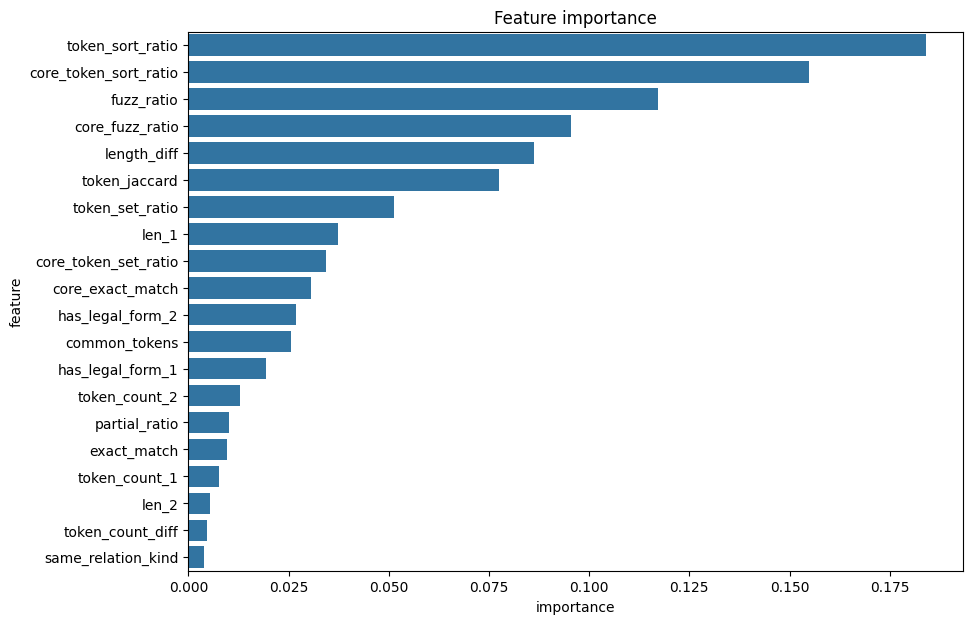

In [11]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = feature_importance_df(
    best_model,
    feature_cols,
)

display(importance.head(25))

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance.head(20),
    x="importance",
    y="feature",
)

plt.title("Feature importance")
plt.show()

In [12]:
# ============================================================
# ERROR ANALYSIS DATAFRAME
# ============================================================

test_errors = test.copy()

test_errors["prediction"] = test_pred
test_errors["score"] = test_score

false_positives = test_errors[
    (test_errors["label"] == 0)
    &
    (test_errors["prediction"] == 1)
]

false_negatives = test_errors[
    (test_errors["label"] == 1)
    &
    (test_errors["prediction"] == 0)
]

print(f"False positives: {len(false_positives):,}")
print(f"False negatives: {len(false_negatives):,}")

False positives: 19
False negatives: 0


In [13]:
# ============================================================
# FALSE POSITIVE EXAMPLES
# ============================================================

display(
    false_positives[
        [
            "party_name_1",
            "party_name_2",
            "name_latin_1",
            "name_latin_2",
            "score",
            "pair_type",
            "fuzz_ratio",
            "token_set_ratio",
            "core_token_set_ratio",
            "token_jaccard",
        ]
    ]
    .sort_values("score", ascending=False)
    .head(30)
)

,party_name_1,party_name_2,name_latin_1,name_latin_2,score,pair_type,fuzz_ratio,token_set_ratio,core_token_set_ratio,token_jaccard
652,Амонов Одинаҳмад Нуруллоевич,Амонов Одинахмад Нуруллоевич,amonov odinaҳmad nurulloevich,amonov odinahmad nurulloevich,0.999957,hard_negative_similar_name,96.551724,96.551724,96.551724,0.500000
14299,Амонов Одинахмад Нуруллоевич,Амонов Одинаҳмад Нуруллоевич,amonov odinahmad nurulloevich,amonov odinaҳmad nurulloevich,0.999957,hard_negative_similar_name,96.551724,96.551724,96.551724,0.500000
2794,Амонов Одинахмад Нуруллоевич,Амонов Одинаҳмад Нуруллоевич,amonov odinahmad nurulloevich,amonov odinaҳmad nurulloevich,0.999947,hard_negative_similar_name,96.551724,96.551724,96.551724,0.500000
7286,Амонов Одинахмад Нуруллоевич,Амонов Одинаҳмад Нуруллоевич,amonov odinahmad nurulloevich,amonov odinaҳmad nurulloevich,0.999947,hard_negative_similar_name,96.551724,96.551724,96.551724,0.500000
10771,Абдуллоев Начмиддин Хайруллоевич,Абдуллоев Начмиддин Хайруллоевич,abdulloev nachmiddin hai rulloevich,abdulloev nachmiddin hai rulloevich,0.999946,hard_negative_similar_name,100.000000,100.000000,100.000000,1.000000
7424,Абдулаев Абдумуталиб Пулатжанович,Абдулоев Абдумуталиб Пулатжанович,abdulaev abdumutalib pulatzhanovich,abduloev abdumutalib pulatzhanovich,0.993577,hard_negative_similar_name,97.142857,97.142857,97.142857,0.500000
9812,Абдурахмонов Ашраф Ниматҷонович,Абдурахмонов Ашраф Ниматчонович,abdurahmonov ashraf nimatҷonovich,abdurahmonov ashraf nimatchonovich,0.989587,hard_negative_similar_name,95.522388,95.522388,95.522388,0.500000
3882,Абдурахмонов Ашраф Ниматҷонович,Абдурахмонов Ашраф Ниматчонович,abdurahmonov ashraf nimatҷonovich,abdurahmonov ashraf nimatchonovich,0.989220,hard_negative_similar_name,95.522388,95.522388,95.522388,0.500000
13149,Аминов Абулхайр Иброҳимович,Аминов Абдулхайр Иброхимович,aminov abulhai r ibroҳimovich,aminov abdulhai r ibrohimovich,0.973993,hard_negative_similar_name,94.915254,94.915254,94.915254,0.333333
3703,Аминов Абдулхайр Иброхимович,Аминов Абулхайр Иброҳимович,aminov abdulhai r ibrohimovich,aminov abulhai r ibroҳimovich,0.968026,hard_negative_similar_name,94.915254,94.915254,94.915254,0.333333


In [14]:
# ============================================================
# SAVE ML BASELINE RESULTS
# ============================================================

valid_results.to_parquet(
    "../data/processed/ml_baseline_valid_results.parquet",
    index=False,
)

pd.DataFrame([test_metrics]).to_parquet(
    "../data/processed/ml_baseline_test_results.parquet",
    index=False,
)

test_errors.to_parquet(
    "../data/processed/ml_baseline_test_predictions.parquet",
    index=False,
)

print("Saved ML baseline results.")

Saved ML baseline results.


In [15]:
import joblib

model_path = "../data/artifacts/random_forest_matcher.joblib"

joblib.dump(
    best_model,
    model_path,
)

print(f"Saved model to: {model_path}")

Saved model to: ../data/artifacts/random_forest_matcher.joblib
